In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64

az.style.use("arviz-darkgrid")

import warnings
from _fitting.model_utils import elpd_to_row


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline

---

In [ ]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return img_base64

def go(m, stat_name='rh', var_names=['intercept', 'sigma', 'sigma_w', 'w'], spline=True, tune=1000, draws=4000):
    with model_dict[m]:
        s0 = time.time()
        idata_dict[m] = pm.sample(
            tune=tune,
            draws=draws,
            chains=4,
            discard_tuned_samples=True,
            nuts_sampler="nutpie",
            store_divergences=True
        )
        s1 = time.time()

        pm.compute_log_likelihood(idata_dict[m], progressbar=False)
        s2 = time.time()

        time_dict[m] = (s1 - s0, s2 - s1)

    # ---------- Summary table ----------
    summary_df = az.summary(idata_dict[m], var_names=var_names)
    summary_html = summary_df.to_html()

    # ---------- Trace plot ----------
    fig_trace = az.plot_trace(idata_dict[m], var_names=var_names)
    fig_trace = fig_trace.ravel()[0].figure
    trace_img = fig_to_base64(fig_trace)

    # ---------- Pair plot ----------
    az.rcParams["plot.max_subplots"] = 200
    ax = az.plot_pair(
        idata_dict[m],
        var_names=var_names,
        textsize=14,
        divergences=True
    )

    for i in range(ax.shape[0]):
        ax[i, 0].yaxis.label.set_rotation(0)
        ax[i, 0].yaxis.label.set_ha('right')

    for j in range(ax.shape[1]):
        ax[0, j].xaxis.label.set_rotation(45)
        ax[0, j].xaxis.label.set_ha('right')

    fig_pair = ax.ravel()[0].figure
    pair_img = fig_to_base64(fig_pair)

    #### WAIC and PSIS LOO
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        eval_waic = az.waic(idata_dict[m])
        eval_psis_loo_elpd = az.loo(idata_dict[m])
    wl_df = pd.DataFrame([elpd_to_row(eval_waic, eval_psis_loo_elpd, m, 'd')])
    wl_html = wl_df.to_html()

    # ---------- Spline plot ----------
    if spline:
        fig_spline = plot_spline_Bknots(
            idata_dict[m],
            stat_name,
            'w',
            'sigma_w',
            B_dict[m],
            x,
            knots=knot_list,
            show_basis=True,
            invert_log=True,
            centred_w=centred_dict[m]
        )
    else:
        fig_spline = fig_trace  # placeholder
    spline_img = fig_to_base64(fig_spline)

    # ---------- Build HTML ----------
    html_content = f"""
    <html>
    <head>
        <title>Model Report: {m}</title>
        <style>
            body {{ font-family: Arial; margin: 40px; }}
            h1 {{ margin-bottom: 10px; }}
            img {{ margin-top: 20px; max-width: 100%; }}
            table {{ border-collapse: collapse; }}
            th, td {{ padding: 6px 8px; }}
        </style>
    </head>
    <body>
        <h1>Model Report: {m}</h1>

        <h2>Timing</h2>
        <p>Posterior Sampling: {time_dict[m][0]:.2f} seconds</p>
        <p>Log Likelihood Compute: {time_dict[m][1]:.2f} seconds</p>

        <h2>Summary</h2>
        {summary_html}
        <h2>WAIC and PSIS LOO</h2>
        {wl_html}

        <h2>Trace Plot</h2>
        <img src="data:image/png;base64,{trace_img}">

        <h2>Pair Plot</h2>
        <img src="data:image/png;base64,{pair_img}">

        <h2>Spline Plot</h2>
        <img src="data:image/png;base64,{spline_img}">
    </body>
    </html>
    """

    with open(f"{m}.html", "w") as f:
        f.write(html_content)

    print(f"Saved report to {m}.html")


In [28]:
def go(m, stat_name='rh', var_names=['intercept', 'sigma', 'sigma_w', 'w'],
       spline=True, tune=1000, draws=4000, compute_idata=True, target_accept=0.8):
    with model_dict[m]:
        if compute_idata:
            s0 = time.time()
            idata_dict[m] = pm.sample(
                tune=tune,
                draws=draws,
                chains=4,
                discard_tuned_samples=True,
                nuts_sampler="nutpie",
                store_divergences=True,
                target_accept=target_accept
            )
            s1 = time.time()

            pm.compute_log_likelihood(idata_dict[m], progressbar=False)
            s2 = time.time()

            time_dict[m] = (s1 - s0, s2 - s1)

    # ---------- Summary table ----------
    summary_df = az.summary(idata_dict[m], var_names=var_names)
    summary_html = summary_df.to_html()

    # ---------- Trace plot ----------
    fig_trace = az.plot_trace(idata_dict[m], var_names=var_names)
    fig_trace = fig_trace.ravel()[0].figure
    trace_img = fig_to_base64(fig_trace)

    # ---------- Pair plot ----------
    az.rcParams["plot.max_subplots"] = 200
    ax = az.plot_pair(
        idata_dict[m],
        var_names=var_names,
        textsize=14,
        divergences=True
    )

    for i in range(ax.shape[0]):
        ax[i, 0].yaxis.label.set_rotation(0)
        ax[i, 0].yaxis.label.set_ha('right')

    for j in range(ax.shape[1]):
        ax[0, j].xaxis.label.set_rotation(45)
        ax[0, j].xaxis.label.set_ha('right')

    fig_pair = ax.ravel()[0].figure
    pair_img = fig_to_base64(fig_pair)

    #### WAIC and PSIS LOO
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        eval_waic = az.waic(idata_dict[m])
        eval_psis_loo_elpd = az.loo(idata_dict[m])
    wl_df = pd.DataFrame([elpd_to_row(eval_waic, eval_psis_loo_elpd, m, 'd')])
    wl_html = wl_df.to_html()

    # ---------- Spline plot ----------
    if spline:
        fig_spline = plot_spline_Bknots(
            idata_dict[m],
            stat_name,
            f'w({stat_name})',
            f'sigma_w({stat_name})',
            B_dict[m],
            data[stat_name].values,
            knots=knot_list,
            show_basis=True,
            invert_log=True,
            centred_w=centred_dict[m]
        )
    else:
        fig_spline = fig_trace  # placeholder
    spline_img = fig_to_base64(fig_spline)

    # ---------- Build HTML ----------
    html_content = f"""
    <html>
    <head>
        <title>Model Report: {m}</title>
        <style>
            body {{ font-family: Arial; margin: 40px; }}
            h1 {{ margin-bottom: 10px; }}
            img {{ margin-top: 20px; max-width: 100%; }}
            table {{ border-collapse: collapse; }}
            th, td {{ padding: 6px 8px; }}
        </style>
    </head>
    <body>
        <h1>Model Report: {m}</h1>

        <h2>Timing</h2>
        <p>Posterior Sampling: {time_dict[m][0]:.2f} seconds</p>
        <p>Log Likelihood Compute: {time_dict[m][1]:.2f} seconds</p>

        <h2>Summary</h2>
        {summary_html}
        <h2>WAIC and PSIS LOO</h2>
        {wl_html}

        <h2>Trace Plot</h2>
        <img src="data:image/png;base64,{trace_img}">

        <h2>Pair Plot</h2>
        <img src="data:image/png;base64,{pair_img}">

        <h2>Spline Plot</h2>
        <img src="data:image/png;base64,{spline_img}">
    </body>
    </html>
    """

    with open(f"{m}.html", "w") as f:
        f.write(html_content)

    print(f"Saved report to {m}.html")


In [29]:
def plot_link(x, idata, var_names=['zi_b0', 'zi_b1'], link='logit', scale_x=1.0):
    x_mean = np.mean(x)
    x_std_dev = np.std(x)
    
    b0_samples = idata.posterior[var_names[0]].values.flatten()
    b1_samples = idata.posterior[var_names[1]].values.flatten()

    x0_samples = -b0_samples / (b1_samples*scale_x) * x_std_dev + x_mean
    x0_mean = np.mean(x0_samples)
    x0_lower = np.percentile(x0_samples, 2.5)
    x0_upper = np.percentile(x0_samples, 97.5)

    link_samples = np.array([b0 + (b1*scale_x) * ((x - x_mean) / x_std_dev) for b0, b1 in zip(b0_samples, b1_samples)])
    def logit_to_prob(logit):
        return 1 / (1 + np.exp(-logit))
    def probit_to_prob(probit):
        from scipy.special import erf
        return 0.5 * (1 + erf(probit / np.sqrt(2)))
    
    if link == 'logit':
        link_samples = logit_to_prob(link_samples)
    elif link == 'probit':
        link_samples = probit_to_prob(link_samples)
    print(link_samples.shape)
    link_mean = link_samples.mean(axis=0)
    link_lower5 = np.percentile(link_samples, 25, axis=0)
    link_upper5 = np.percentile(link_samples, 75, axis=0)
    link_lower = np.percentile(link_samples, 2.5, axis=0)
    link_upper = np.percentile(link_samples, 97.5, axis=0)

    # reorder
    id = np.argsort(x)
    x = x[id]
    link_mean = link_mean[id]
    link_lower5 = link_lower5[id]
    link_upper5 = link_upper5[id]
    link_lower = link_lower[id]
    link_upper = link_upper[id]
    link_hdi = np.array([link_lower, link_upper]).T
    plt.figure(figsize=(8, 5))

    plt.axvline(x0_mean, color='red', linestyle='--', label='Mean x0')
    plt.axvline(x0_lower, color='red', linestyle=':', label='95% CI x0')
    plt.axvline(x0_upper, color='red', linestyle=':')

    plt.plot(x, link_mean, label='Mean Link', color='blue')
    plt.fill_between(x, link_hdi[:, 0], link_hdi[:, 1], color='blue', alpha=0.3, label='95% HDI')
    plt.xlabel('x')
    plt.ylabel('Link(psi)')
    plt.title(f'Posterior of {link.capitalize()} vs x')
    plt.legend()
    plt.grid()
    return plt.gcf()

---

In [30]:
data = read_in(folder, admin=2, max_lag=6, dropna=True, end_year=2017, end_month=12)

In [31]:
x_t2m = data['t2m_mean_pop_weighted(0)'].values
x_t2m_mean = np.mean(x_t2m)
x_t2m_std_dev = np.std(x_t2m)
x_t2m_std = (x_t2m - x_t2m_mean) / x_t2m_std_dev

In [14]:
%matplotlib inline

In [23]:
np.max(data['rate']), np.max(data['cases'])

(0.0044615164384215296, 1276.0)

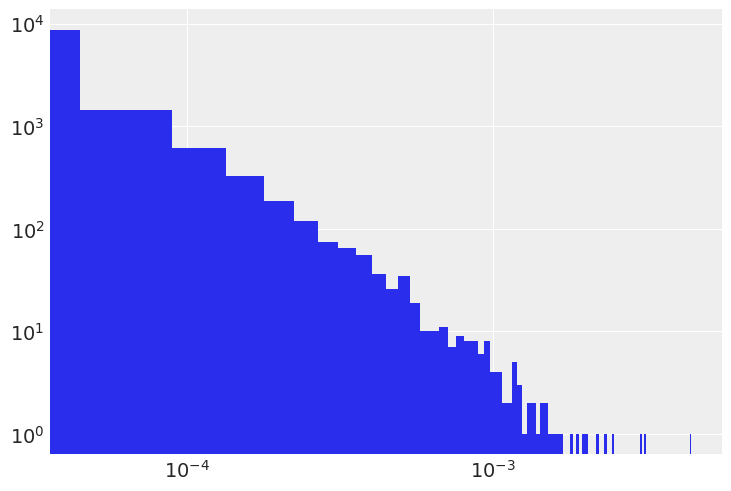

In [ ]:
plt.hist(data['rate'], bins=100)
plt.xscale('log')
plt.yscale('log')
plt.show()

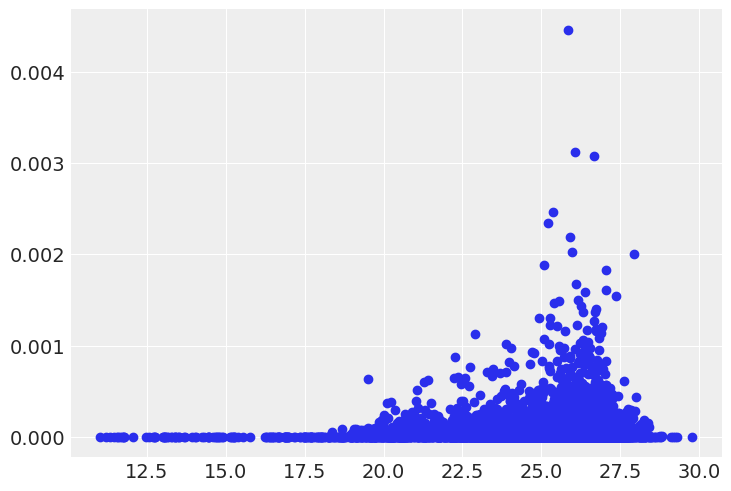

In [21]:
plt.scatter(data['t2m_mean_pop_weighted(0)'], data['rate'])
plt.show()

In [8]:
cutoff = 19.0

In [33]:
model_dict = {}
B_dict = {}
idata_dict = {}
time_dict = {}
centred_dict = {}

In [34]:
intercept_sigma = 1.0
intercept_mu = -10.0
beta_u_sigma = 1.0
disp_sigma = 1.0

urbanisation_name = 'urbanisation_pop_weighted_std'
knot_type = 'quantile'
degree = 3
num_knots = 5

sigma_w_nu = 1.0
sigma_w_sigma = 1.0

In [37]:
m = 'NB intercept + urbanisation halfcauchy'
model = pm.Model()
with model:
    # Priors
    alpha = pm.HalfCauchy("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Likelihood
    y_obs = pm.NegativeBinomial('y_obs', mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])


model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [38]:
print(m)
go(m, var_names=['intercept', 'beta_u', 'alpha'],
   spline=False, tune=1000, draws=2000, target_accept=0.8, compute_idata=True)

NB intercept + urbanisation halfcauchy


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,1.16,3
,3000,0,1.09,3
,3000,0,0.98,3
,3000,0,1.02,3


Saved report to NB intercept + urbanisation halfcauchy.html


In [10]:
m = 'intercept + urbanisation + ZINB logit()'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b0 = pm.Normal("zi_b0", mu=13.0, sigma=0.5)
    zi_b1 = pm.Normal("zi_b1", mu=4.0, sigma=0.5)
    zi_c = pm.Deterministic("zi_c", - zi_b0/zi_b1)
    zi_x = zi_b0 + zi_b1 * x_t2m_std

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [11]:
b1_mu = 5.1
m = f'intercept + urbanisation + ZINB logit() c rep0 m{b1_mu}'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1 = pm.Normal("zi_b1", mu=b1_mu, sigma=0.5)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_t2m_std

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [14]:
b1_mu = 5.1
m = f'intercept + urbanisation + ZINB logit() c rep0 m{b1_mu} non-centred'


model = pm.Model()
with model:
    x_t2m_std_data = pm.Data("x_t2m_std_data", x_t2m_std)
    
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    zi_b1 = pm.Deterministic("zi_b1", zi_b1_raw * 0.5 + b1_mu)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 *  x_t2m_std_data

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [1]:
data['rate']

NameError: name 'data' is not defined

In [15]:
print(m)
go(m, var_names=['intercept', 'beta_u', 'alpha', 'zi_b0', 'zi_c', 'zi_b1'],
   spline=False, tune=1000, draws=2000, target_accept=0.8, compute_idata=True)

intercept + urbanisation + ZINB logit() c rep0 m5.1 non-centred


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,2,0.92,3
,3000,3,0.94,7
,3000,2,1.04,3
,3000,2,1.02,3


Saved report to intercept + urbanisation + ZINB logit() c rep0 m5.1 non-centred.html


(8000, 11886)


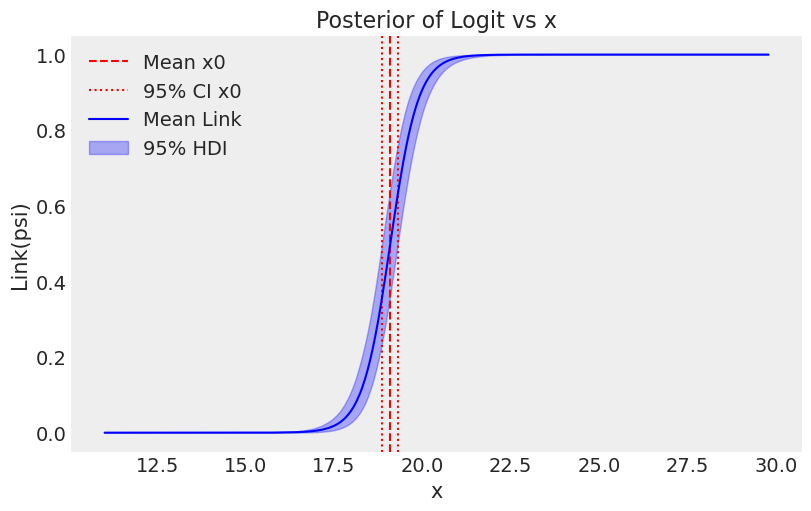

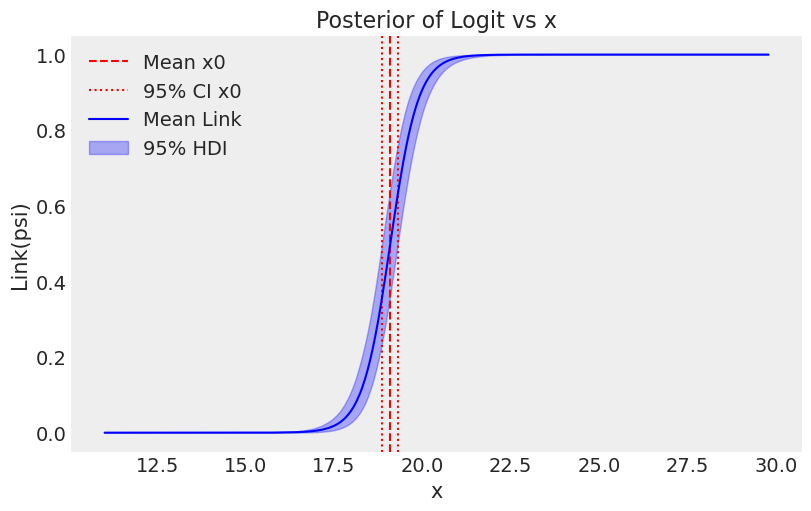

In [70]:
plot_link(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'], link='logit', scale_x=1.0)

In [10]:
m = 'intercept + urbanisation + ZINB logit() rep4'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1 = pm.Normal("zi_b1", mu=2.0, sigma=1.0)
    # zi_b1_ = pm.HalfNormal("zi_b1_", sigma=1.5)
    # zi_b1 = pm.Deterministic("zi_b1", zi_b1_+0.5)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_t2m_std

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [11]:
x_t2m_std_half = x_t2m_std / 2
m = 'intercept + urbanisation + ZINB logit() rep5 m0.0 s3.0'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1_mu, zi_b1_sd = 0.0, 3.0
    zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    zi_b1 = pm.Deterministic("zi_b1", (zi_b1_raw + zi_b1_mu) * zi_b1_sd)
    # zi_b1_ = pm.HalfNormal("zi_b1_", sigma=1.5)
    # zi_b1 = pm.Deterministic("zi_b1", zi_b1_+0.5)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_t2m_std_half

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [12]:
x_t2m_std_half = x_t2m_std / 2
m = 'intercept + urbanisation + ZINB probit() rep5 m0.0 s1.0'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1_mu, zi_b1_sd = 0.0, 1.0
    zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    zi_b1 = pm.Deterministic("zi_b1", (zi_b1_raw + zi_b1_mu) * zi_b1_sd)
    # zi_b1_ = pm.HalfNormal("zi_b1_", sigma=1.5)
    # zi_b1 = pm.Deterministic("zi_b1", zi_b1_+0.5)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_t2m_std_half

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invprobit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [13]:
x_t2m_std_fourth = x_t2m_std / 4
m = 'intercept + urbanisation + ZINB logit() rep5 m0.0 s3.0 fourth'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1_mu, zi_b1_sd = 0.0, 4.2
    zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    zi_b1 = pm.Deterministic("zi_b1", (zi_b1_raw + zi_b1_mu) * zi_b1_sd)
    # zi_b1_ = pm.HalfNormal("zi_b1_", sigma=1.5)
    # zi_b1 = pm.Deterministic("zi_b1", zi_b1_+0.5)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_t2m_std_fourth

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

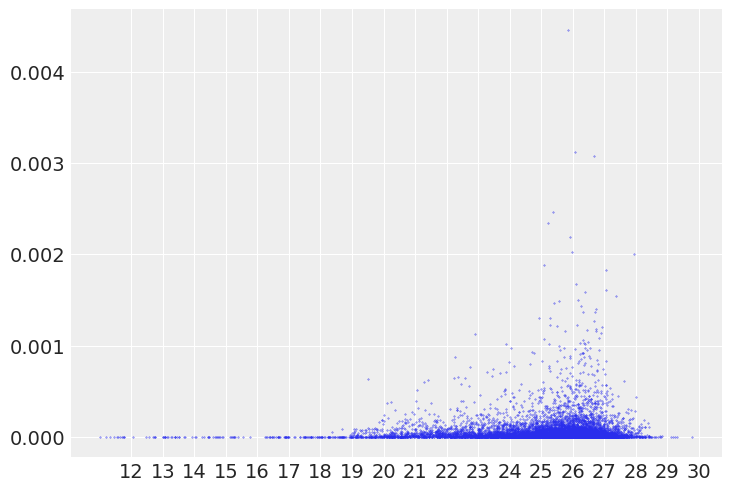

In [44]:
plt.scatter(data['t2m_mean_pop_weighted(0)'], data['rate'], s=0.1)
plt.xticks(np.arange(12, 31))
plt.show()

In [33]:
scale = 1
x_t2m_std_scaled = x_t2m_std / scale
prior_b1_mu = 4.0
prior_b1_sd = 1.0
scaled_b1_mu = prior_b1_mu * scale
scaled_b1_sd = prior_b1_sd * scale

m = f'intercept + urbanisation + ZINB logit() rep5 scale{scale} m{prior_b1_mu} sd{prior_b1_sd}'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    zi_b1_scaled = pm.Deterministic("zi_b1_scaled", (zi_b1_raw + scaled_b1_mu) * scaled_b1_sd)

    zi_b1 = pm.Deterministic("zi_b1", zi_b1_scaled/scale)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1_scaled * x_t2m_std_scaled

    closest_x0 = pm.Deterministic("closest_x0", pm.math.min(pm.math.abs(x_t2m_std_scaled - zi_c/scale)))

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [17]:
scale = 1
x_t2m_std_scaled = x_t2m_std / scale
prior_b1_mu = 1.0
prior_b1_sd = 0.5
scaled_b1_mu = prior_b1_mu * scale
scaled_b1_sd = prior_b1_sd * scale

m = f'intercept + urbanisation + ZINB logit() rep6 scale{scale} m{prior_b1_mu} sd{prior_b1_sd}'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    #zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    #zi_b1_scaled = pm.Deterministic("zi_b1_scaled", (zi_b1_raw + scaled_b1_mu) * scaled_b1_sd)

    # zi_b1 = pm.Deterministic("zi_b1", zi_b1_scaled/scale)
    zi_b1_scaled
    zi_w = pm.Normal("zi_w", mu=scaled_b1_mu, sigma=scaled_b1_sd)
    zi_b1_scaled = pm.Deterministic("zi_b1_scaled", (1/zi_w))
    zi_b1 = pm.Deterministic("zi_b1", zi_b1_scaled/scale)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_c_rescaled = pm.Deterministic("zi_c_rescaled", zi_c*x_t2m_std_dev + x_t2m_mean)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c/zi_w)
    zi_x = zi_b0 + x_t2m_std_scaled/zi_w

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [43]:
scale = 0.5
x_t2m_std_scaled = x_t2m_std / scale
prior_b1_mu = 0.0
prior_b1_sd = 2.0
scaled_b1_mu = prior_b1_mu * scale
scaled_b1_sd = prior_b1_sd * scale

m = f'intercept + urbanisation + ZINB logit() rep5 sample_scaled scale{scale} m{prior_b1_mu} sd{prior_b1_sd}'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    #zi_b1_raw = pm.Normal("zi_b1_raw", mu=0.0, sigma=1.0)
    #zi_b1_scaled = pm.Deterministic("zi_b1_scaled", (zi_b1_raw + scaled_b1_mu) * scaled_b1_sd)
    zi_b1_scaled = pm.Normal("zi_b1_scaled", mu=scaled_b1_mu, sigma=scaled_b1_sd)

    zi_b1 = pm.Deterministic("zi_b1", zi_b1_scaled/scale)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_t2m_mean) / x_t2m_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1_scaled * x_t2m_std_scaled

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [20]:
m = 'intercept + urbanisation + ZINB logit() rep3'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b0 = pm.Normal("zi_b0", mu=13.0, sigma=0.5)
    zi_b1 = pm.Normal("zi_b1", mu=4.0, sigma=0.5)
    zi_c = pm.Deterministic("zi_c", - zi_b0/zi_b1)
    zi_x = zi_b1 * (x_t2m_std - zi_c)

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [21]:
m = 'intercept + urbanisation + ZINB logit() rep2'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b0 = pm.Normal("zi_b0", mu=13.0, sigma=0.5)
    zi_b1 = pm.Normal("zi_b1", mu=4.0, sigma=0.5)
    log_zi_x = pm.math.log(zi_b1) + pm.math.log(x_t2m_std - zi_b0)
    zi_x = pm.math.exp(log_zi_x)
    #zi_x = zi_b1 * (x_t2m_std - zi_b0)
    

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [22]:
(19.0 - x_t2m_mean) / x_t2m_std_dev

-3.1475626904126006

In [34]:
print(m)
go(m, var_names=['intercept', 'beta_u', 'alpha', 'zi_b0', 'zi_c', 'zi_b1', 'closest_x0'],
   spline=False, tune=1000, draws=2000, target_accept=0.9, compute_idata=True)

intercept + urbanisation + ZINB logit() rep5 scale1 m4.0 sd1.0


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,5,0.73,7
,3000,16,0.78,3
,3000,9,0.68,3
,3000,12,0.71,7


Saved report to intercept + urbanisation + ZINB logit() rep5 scale1 m4.0 sd1.0.html


array([[<Axes: ylabel='beta_u'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='alpha'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='zi_c'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='intercept', ylabel='zi_b0'>,
        <Axes: xlabel='beta_u'>, <Axes: xlabel='alpha'>,
        <Axes: xlabel='zi_c'>]], dtype=object)

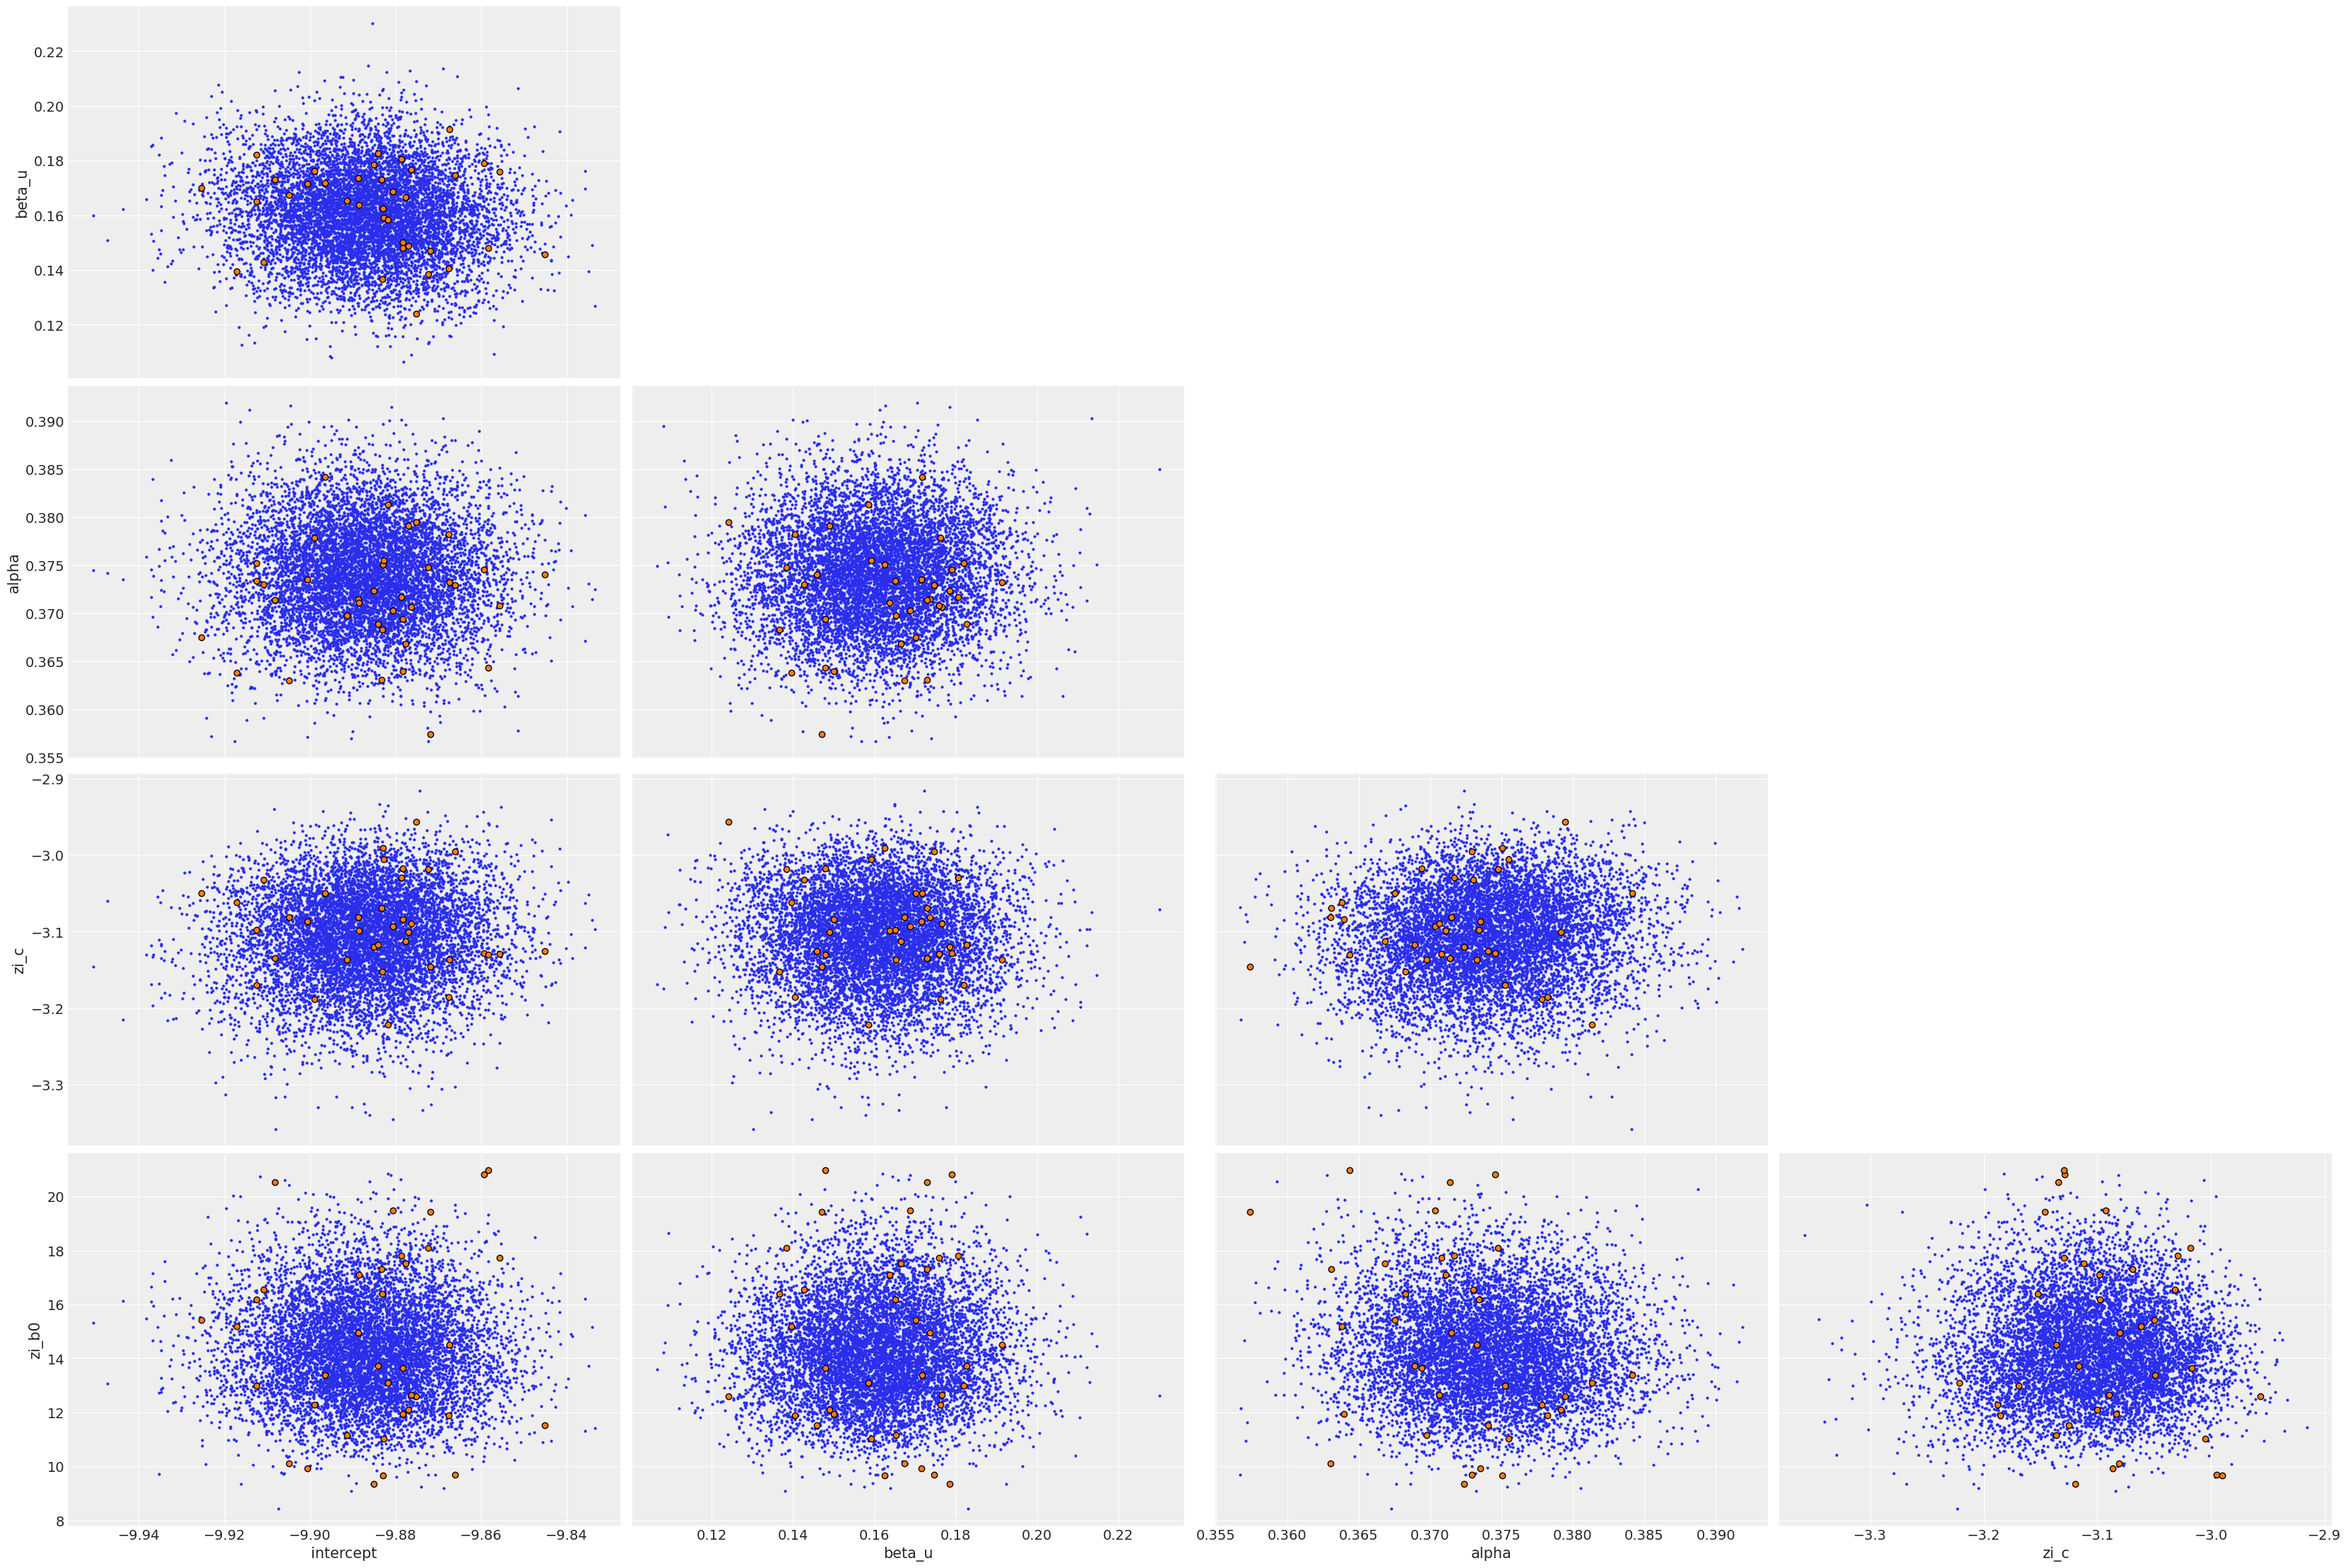

In [28]:
m = 'intercept + urbanisation + ZINB logit() rep5 scale1 m4.0 sd1.0'
fig = az.plot_pair(idata_dict[m], var_names=['intercept', 'beta_u', 'alpha', 'zi_c', 'zi_b0'], divergences=True)
plt.savefig(f'{m}_pairplot.png', bbox_inches='tight', dpi=400)
display(fig)

<Axes: >

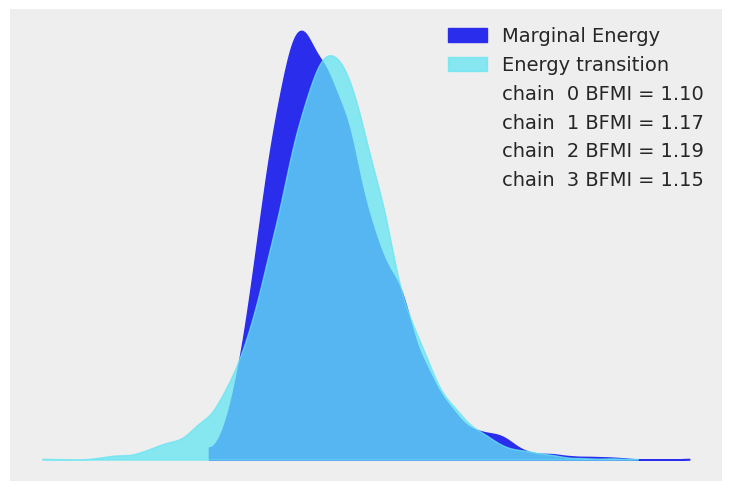

In [63]:
fig = az.plot_energy(idata_dict[m])
display(fig)

In [70]:
m = 'intercept + urbanisation + ZINB logit() rep5'
print(m)
fig = plot_link(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'], link='logit', scale_x=0.5)
display(fig)
plt.close(fig)

intercept + urbanisation + ZINB logit() rep5


KeyError: 'intercept + urbanisation + ZINB logit() rep5'

intercept + urbanisation + ZINB logit() rep5 scale1 m4.0 sd2.0
(8000, 11886)


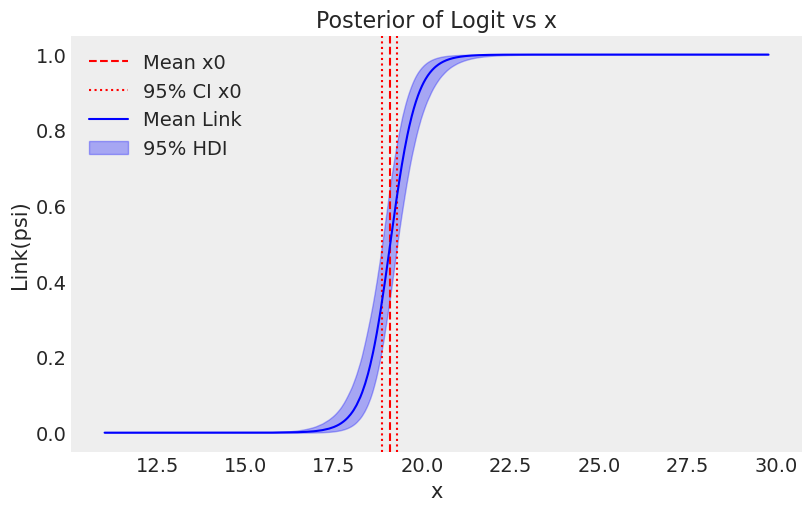

In [71]:
m = 'intercept + urbanisation + ZINB logit() rep5 scale1 m4.0 sd2.0'
print(m)
fig = plot_link(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'], link='logit', scale_x=1.0)
display(fig)
plt.close(fig)

intercept + urbanisation + ZINB logit() rep5 m0.0 s3.0 fourth
(8000, 11886)


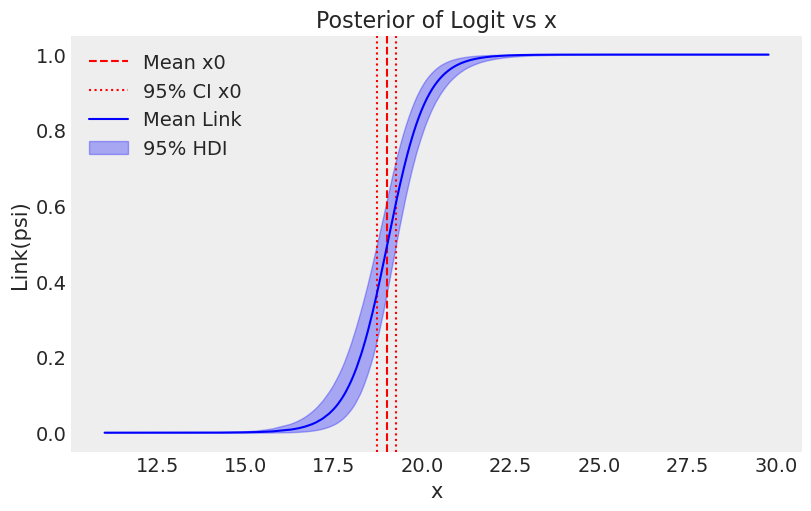

In [24]:
print(m)
fig = plot_link(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'], link='logit', scale_x=0.25)
display(fig)
plt.close(fig)

In [21]:
m = 'intercept + urbanisation + ZINB probit()'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b0 = pm.Normal("zi_b0", mu=0.0, sigma=2.0)
    zi_b1 = pm.Normal("zi_b1", mu=0.0, sigma=2.0)
    zi_x = zi_b0 + zi_b1 * x_t2m_std

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invprobit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

In [22]:
go(m, var_names=['intercept', 'beta_u', 'alpha', 'zi_b0', 'zi_b1'], spline=False, tune=1000, draws=2000)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,1318,0.31,5
,3000,1313,0.24,6
,3000,1184,0.24,5
,3000,1252,0.38,4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved report to intercept + urbanisation + ZINB probit().html


(8000, 11886)


<IPython.core.display.Javascript object>

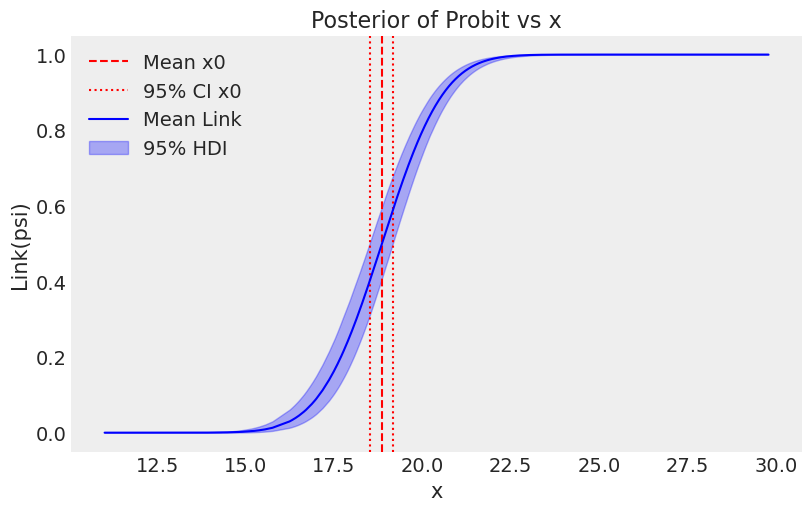

In [23]:
fig = plot_link(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'], link='probit')
display(fig)

---

In [ ]:
m = 'intercept + urbanisation + spline(t2m) halfnormal'

stat_names = ['t2m_mean_pop_weighted(0)']
# stat_names = ['tp_24hmean_pop_weighted_log(0)']
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # splines
    knot_list = {}
    B = {}
    sigma_w = {}
    w = {}
    f = {}
    for stat_name in stat_names:
        d = data[stat_name].values
        if knot_type=='equispaced':
            knot_list[stat_name] = np.linspace(np.min(d), np.max(d), num_knots+2)[1:-1]
        elif knot_type=='quantile':
            knot_list[stat_name] = np.percentile(d, np.linspace(0, 100, num_knots + 2))[1:-1]
        else:
            print('knot_list must be quantile or equispaced')

        B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list[stat_name], "degree":degree})
        B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
        U, S, Vt = np.linalg.svd(B_full_centred, full_matrices=False)
        r = np.sum(S > 1e-10)
        print(f'Rank of B_full_centred is {r}')
        U_r = U[:, :r]
        S_r = S[:r]
        X_r = U_r @ np.diag(S_r)
        print(f'X_r has shape {X_r.shape}')
        B[stat_name] = X_r

        # Spline coefficients
        # sigma_w[stat_name] = pm.HalfNormal(f"sigma_w({stat_name})", sigma=sigma_w_sigma)
        sigma_w[stat_name] = pm.HalfStudentT(f"sigma_w({stat_name})", nu=sigma_w_nu, sigma=sigma_w_sigma)
        w[stat_name] = pm.Normal(f"w({stat_name})", mu=0, sigma=sigma_w[stat_name], size=B[stat_name].shape[1], dims="splines")
    
        f[stat_name] = pm.math.dot(B[stat_name], w[stat_name])

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    surveillance_name = None
    if surveillance_name is not None:
        log_mu += pm.math.log(pm.math.max(data[surveillance_name], pm.math.log(1e-3)))
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]
    for stat_name in stat_names:
        log_mu += f[stat_name]

    # Likelihood
    y_obs = pm.NegativeBinomial('y_obs', mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = X_r
knot_list = knot_list[stat_names[0]]

Rank of B_full_centred is 8
X_r has shape (11886, 8)


In [15]:
go(m, var_names=['intercept', 'beta_u', 'alpha', f'sigma_w({stat_names[0]})', f'w({stat_names[0]})'],
   spline=True, tune=1000, draws=2000, stat_name=stat_names[0], compute_idata=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.35,23
,3000,0,0.37,15
,3000,0,0.35,7
,3000,0,0.38,7


Saved report to intercept + urbanisation + spline(t2m) halfstudent.html


In [11]:
m = 'intercept + urbanisation + spline(t2m) + ZINB logit() halfnormal'

stat_names = ['t2m_mean_pop_weighted(0)']
# stat_names = ['tp_24hmean_pop_weighted_log(1)']
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # splines
    knot_list = {}
    B = {}
    sigma_w = {}
    w = {}
    f = {}
    for stat_name in stat_names:
        d = data[stat_name].values
        if knot_type=='equispaced':
            knot_list[stat_name] = np.linspace(np.min(d), np.max(d), num_knots+2)[1:-1]
        elif knot_type=='quantile':
            knot_list[stat_name] = np.percentile(d, np.linspace(0, 100, num_knots + 2))[1:-1]
        else:
            print('knot_list must be quantile or equispaced')

        B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list[stat_name], "degree":degree})
        B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
        U, S, Vt = np.linalg.svd(B_full_centred, full_matrices=False)
        r = np.sum(S > 1e-10)
        print(f'Rank of B_full_centred is {r}')
        U_r = U[:, :r]
        S_r = S[:r]
        X_r = U_r @ np.diag(S_r)
        X_r = np.ascontiguousarray(X_r)  # ensure X_r is C-contiguous for PyMC
        print(f'X_r has shape {X_r.shape}')
        B[stat_name] = X_r

        # Spline coefficients
        sigma_w[stat_name] = pm.HalfNormal(f"sigma_w({stat_name})", sigma=sigma_w_sigma)
        # sigma_w[stat_name] = pm.HalfStudentT(f"sigma_w({stat_name})", nu=sigma_w_nu, sigma=sigma_w_sigma)
        w[stat_name] = pm.Normal(f"w({stat_name})", mu=0, sigma=sigma_w[stat_name], size=B[stat_name].shape[1], dims="splines")
    
        f[stat_name] = pm.math.dot(B[stat_name], w[stat_name])

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    surveillance_name = None
    if surveillance_name is not None:
        log_mu += pm.math.log(pm.math.max(data[surveillance_name], pm.math.log(1e-3)))
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]
    for stat_name in stat_names:
        log_mu += f[stat_name]

    # Zero-inflation component
    zi_b0 = pm.Normal("zi_b0", mu=0, sigma=1.0)
    zi_b1 = pm.Normal("zi_b1", mu=0, sigma=1.0)
    zi_x = zi_b0 + zi_b1 * x_t2m_std
    
    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None
B_dict[m] = X_r
knot_list = knot_list[stat_names[0]]

Rank of B_full_centred is 8
X_r has shape (11886, 8)


In [14]:
go(m, var_names=['intercept', 'beta_u', 'alpha', 'zi_b0', 'zi_b1', f'sigma_w({stat_names[0]})', f'w({stat_names[0]})'],
   spline=True, tune=1000, draws=2000, stat_name=stat_names[0])

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,20,0.44,15
,3000,61,0.44,15
,3000,33,0.45,15
,3000,18,0.42,15


Saved report to intercept + urbanisation + spline(t2m) + ZINB logit() halfnormal.html


In [13]:
%matplotlib notebook

(8000, 11886)


<IPython.core.display.Javascript object>

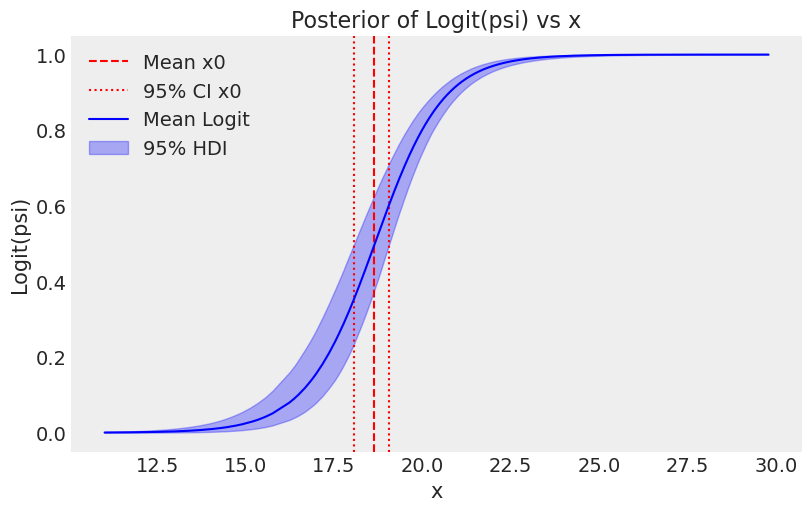

In [22]:
fig = plot_logit(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'])
display(fig)

In [12]:
m = 'intercept + urbanisation + spline(t2m) + ZINB logit() halfnormal + cutoff'

stat_names = ['t2m_mean_pop_weighted(0)']
# stat_names = ['tp_24hmean_pop_weighted_log(1)']
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # splines
    knot_list = {}
    B = {}
    sigma_w = {}
    w = {}
    f = {}
    for stat_name in stat_names:
        d = data[stat_name].values
        if stat_name == 't2m_mean_pop_weighted(0)':
            d = np.clip(d, cutoff, None)
        if knot_type=='equispaced':
            knot_list[stat_name] = np.linspace(np.min(d), np.max(d), num_knots+2)[1:-1]
        elif knot_type=='quantile':
            knot_list[stat_name] = np.percentile(np.unique(d), np.linspace(0, 100, num_knots + 2))[1:-1]
        else:
            print('knot_list must be quantile or equispaced')

        B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list[stat_name], "degree":degree})
        B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
        U, S, Vt = np.linalg.svd(B_full_centred, full_matrices=False)
        r = np.sum(S > 1e-10)
        print(f'Rank of B_full_centred is {r}')
        U_r = U[:, :r]
        S_r = S[:r]
        X_r = U_r @ np.diag(S_r)
        X_r = np.ascontiguousarray(X_r)  # ensure X_r is C-contiguous for PyMC
        print(f'X_r has shape {X_r.shape}')
        B[stat_name] = X_r

        # Spline coefficients
        sigma_w[stat_name] = pm.HalfNormal(f"sigma_w({stat_name})", sigma=sigma_w_sigma)
        # sigma_w[stat_name] = pm.HalfStudentT(f"sigma_w({stat_name})", nu=sigma_w_nu, sigma=sigma_w_sigma)
        w[stat_name] = pm.Normal(f"w({stat_name})", mu=0, sigma=sigma_w[stat_name], size=B[stat_name].shape[1], dims="splines")
    
        f[stat_name] = pm.math.dot(B[stat_name], w[stat_name])

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    surveillance_name = None
    if surveillance_name is not None:
        log_mu += pm.math.log(pm.math.max(data[surveillance_name], pm.math.log(1e-3)))
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]
    for stat_name in stat_names:
        log_mu += f[stat_name]

    # Zero-inflation component
    zi_b0 = pm.Normal("zi_b0", mu=0, sigma=10.0)
    zi_b1 = pm.Normal("zi_b1", mu=0, sigma=10.0)
    zi_x = zi_b0 + zi_b1 * x_t2m_std
    
    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None
B_dict[m] = X_r
knot_list = knot_list[stat_names[0]]

Rank of B_full_centred is 8
X_r has shape (11886, 8)


In [13]:
go(m, var_names=['intercept', 'beta_u', 'alpha', 'zi_b0', 'zi_b1', f'sigma_w({stat_names[0]})', f'w({stat_names[0]})'],
   spline=True, tune=1000, draws=2000, stat_name=stat_names[0])

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,179,0.33,15
,3000,161,0.29,31
,3000,176,0.32,31
,3000,163,0.38,15


Saved report to intercept + urbanisation + spline(t2m) + ZINB logit() halfnormal + cutoff.html


(8000, 11886)


<IPython.core.display.Javascript object>

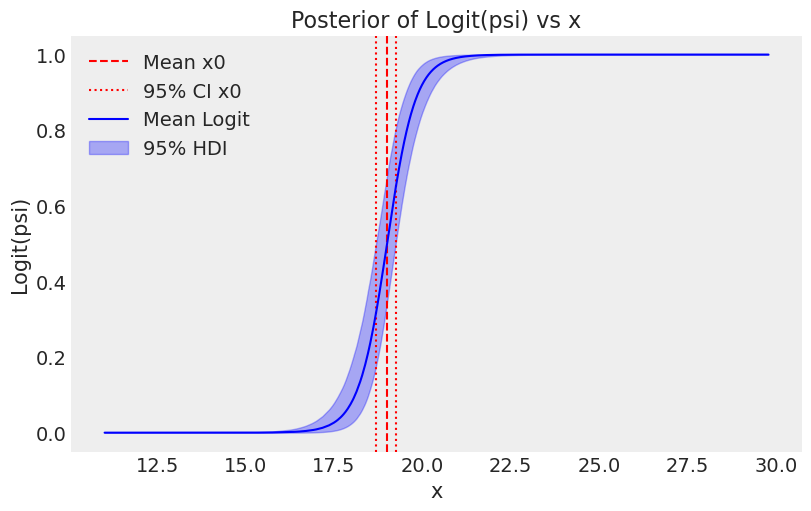

In [18]:
fig = plot_logit(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'])
display(fig)

(8000, 11886)


<IPython.core.display.Javascript object>

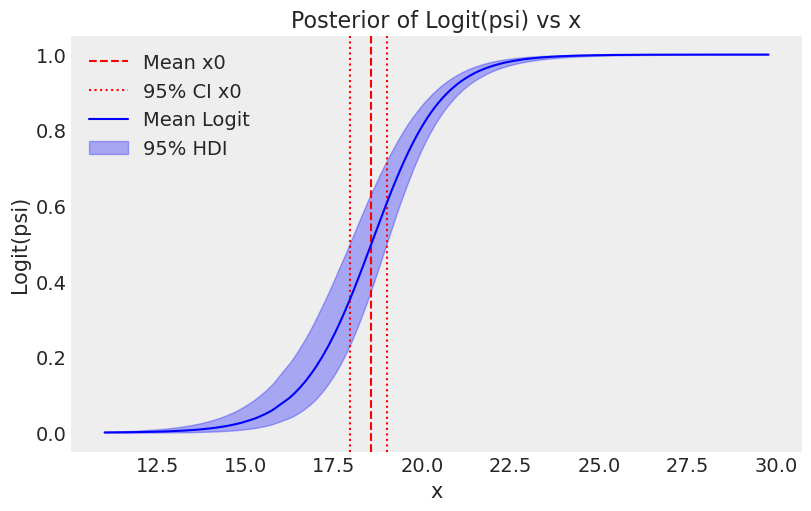

In [26]:
fig = plot_logit(x_t2m, idata_dict[m], var_names=['zi_b0', 'zi_b1'])
display(fig)

---